In [213]:
import referenceFrames as rf
import numpy as np
from math import sin, cos, tan, asin, atan, radians, degrees
import shapely.geometry as sg
import matplotlib.pyplot as plt
import descartes
from scipy import constants
import descartes

import imp
imp.reload(rf)

<module 'referenceFrames' from '/Users/sara/work/Instrumentation/Plato/softwareDevelopment/Platosim3/python/referenceFrames.py'>

In [214]:
focalLength = 247.52     # [mm]
pixelSize = 18     # [µm]
plateScale = 15     # [arcsec]
numGroups = 4
numCorners = 4
ccdCodes = ["1", "2", "3", "4"]
linestyles = [(0,(5,15)), "-.", (0,(.5,2)), "--"]
tiltAngles = [9.2, 9.2, 9.2, 9.2]     # [degrees]
azimuthAngles = [45.0, 135.0, -135.0, -45.0]     # [degrees]

In [215]:
def rotate_origin_only(x, y, angle):

    """
    Rotate point (x, y) around the origin over the given angle.
    
    :param x: Point's x-coordinate.
    
    :param y: Point's y-coordinate.
    
    :param angle: Rotation angle [degrees].  A positive (negative) angle corresponds to
                  a counterclockwise (clockwise) rotation.
    
    :return xRot: Point's x-coordinate after rotation.
    
    :return yRot: Point's y-coordinate after rotation.
    """
    
    angleRadians = radians(angle)     # [degrees] -> [radians]
    
    xRot = cos(angleRadians) * x - sin(angleRadians) * y
    yRot = sin(angleRadians) * x + cos(angleRadians) * y

    return xRot, yRot

In [216]:
def mm2pixels(distanceMm):
    
    """
    Conversion from millimeters to pixels.
    
    :param distanceMm: Distance [mm].
    
    :return distancePixels: Distance [pixels].
    """
    
    distancePixels = degrees(atan(distanceMm / focalLength)) / plateScale * constants.degree / constants.arcsec
    
    return distancePixels

In [217]:
sign = lambda x: (1, -1)[x < 0]

In [218]:
# Size of the FOV

fovDegrees = 18.8876
fovPixels = fovDegrees / plateScale * constants.degree / constants.arcsec
fovMm = focalLength * tan(radians(fovDegrees))

In [235]:
colors = ['r', 'b', 'orange', 'g']

# Telescope pointing w.r.t. platform pointing

In [236]:
# Arbitrary choice of platform pointing and solar-panel orientation

raPlatform = 10.     # [degrees]
decPlatform = 10.     # [degrees]
solarPanelOrientation = 0.     # [degrees]

raSun, decSun = rf.sunSkyCoordinatesAwayfromPlatformPointing(radians(raPlatform), radians(decPlatform), solarPanelOrientation)

In [237]:
raTelescope = []
decTelescope = []

for group in range(0, numGroups):
    
    # Telescope pointing (absolute)
    
    ra, dec = rf.platformToTelescopePointingCoordinates(radians(raPlatform), radians(decPlatform), raSun, decSun, radians(azimuthAngles[group]), radians(tiltAngles[group]))     # [radians]
    
    # Telescope pointing w.r.t. platform pointing
    
    raTelescope.append(degrees(ra) - raPlatform)     # [degrees]
    decTelescope.append(degrees(dec) - decPlatform)     # [degrees]
    
meanDist = (np.mean(np.absolute(raTelescope)) + np.mean(np.absolute(decTelescope))) / 2.0

for group in range(numGroups):
    
    raTelescope[group] = sign(raTelescope[group]) * meanDist
    decTelescope[group] = sign(decTelescope[group]) * meanDist

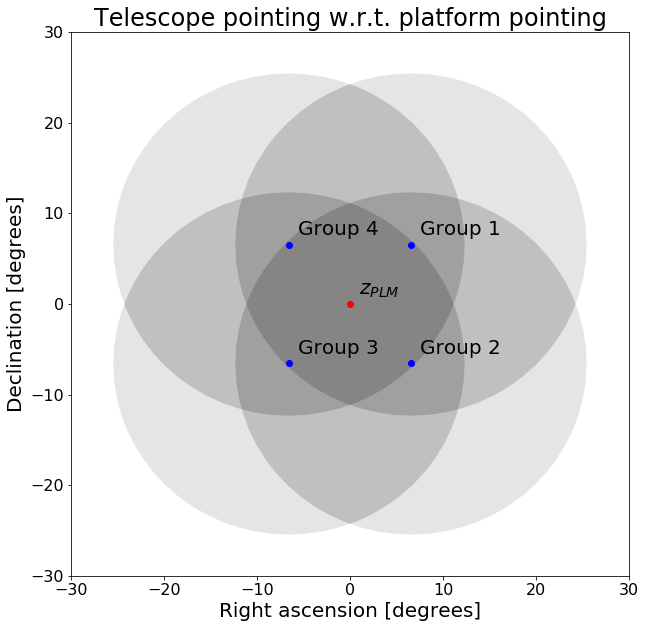

In [238]:
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111)

ax.plot([raPlatform - raPlatform], [decPlatform - decPlatform], "ro")
ax.plot(raTelescope, decTelescope, "bo")

offset = 1

for group in range(numGroups):
    
    ax.text(raTelescope[group] + offset, decTelescope[group] + offset, "Group " + str(group + 1), fontsize = 20)

ax.text(0 + offset, 0 + offset, "$z_{PLM}$", fontsize = 20)
    
circles = []
for group in range(numGroups):
    circles.append(sg.Point(raTelescope[group], decTelescope[group]).buffer(fovDegrees))

for index in range(numGroups):
    
    one = circles[index].intersection(circles[index])
    ax.add_patch(descartes.PolygonPatch(one, fc='gray', ec='none', alpha=0.2))
    
    two = circles[index].intersection(circles[(index + 1) % numCorners])
    ax.add_patch(descartes.PolygonPatch(two, fc='gray', ec='none', alpha=0.2))
    
    three = circles[index].intersection(circles[(index + 1) % numCorners]).intersection(circles[(index + 2) % numCorners])
    ax.add_patch(descartes.PolygonPatch(three, fc='gray', ec='none', alpha=0.2))
    
four = circles[0].intersection(circles[1]).intersection(circles[2]).intersection(circles[3])
ax.add_patch(descartes.PolygonPatch(four, fc='gray', ec='none', alpha=0.2))
    
ax.set_title('Telescope pointing w.r.t. platform pointing', fontsize = 24)
ax.set_xlabel('Right ascension [degrees]', fontsize = 20)
ax.set_ylabel('Declination [degrees]', fontsize = 20)
plt.xlim([-30, 30])
plt.ylim([-30, 30])
plt.xticks(fontsize = 16)
plt.yticks(fontsize = 16)

plt.show()

# Focal plane (origin at optical axis)

In [239]:
xFP = np.array([])
yFP = np.array([])

offset = 4

# Calculate the coordinates of the telescope pointings (for the 4 telescope groups) 
# in the focal-plane reference frame of group 1

for group in range(numGroups):

    xFP1, yFP1 = rf.skyToFocalPlaneCoordinates(radians(raTelescope[group] + raPlatform), radians(decTelescope[group] + decPlatform), radians(raPlatform), radians(decPlatform), 0,  \
                                              radians(tiltAngles[0]), radians(azimuthAngles[0]), 0, focalLength)
    xFP = np.append(xFP, xFP1)
    yFP = np.append(yFP, yFP1)
    
# Make sure the average of the telescope pointings of the 4 telescope groups is at the origin of the reference frame

xAvg = np.mean(xFP)
yAvg = np.mean(yFP)

xFP -= xAvg
yFP -= yAvg

# Rotate everything to make sure that the square connecting the telescope pointings of the 4 telescope groups
# are aligned with the axis of the reference frame.  The telescope pointing for telescope group 1 is in Q2, but
# this is an arbitrary choice.

for group in range(numGroups):
    
    xRot, yRot = rotate_origin_only(xFP[group], yFP[group], -45)
    xFP[group] = xRot
    yFP[group] = yRot

meanDist = (np.mean(np.absolute(xFP)) + np.mean(np.absolute(yFP))) / 2.0

for group in range(numGroups):
    
    xFP[group] = sign(xFP[group]) * meanDist
    yFP[group] = sign(yFP[group]) * meanDist

/Users/sara/anaconda3/envs/platosim/lib/python3.6/site-packages/ipykernel_launcher.py:1: DeprecationWarning: In future, it will be an error for 'np.bool_' scalars to be interpreted as an index
  """Entry point for launching an IPython kernel.


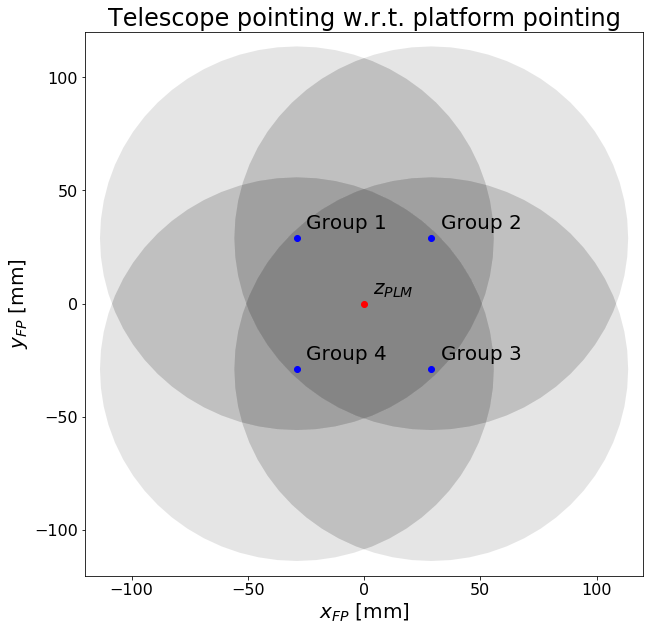

In [240]:
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111)

plt.plot([0], [0], "ro")

plt.plot(xFP, yFP, "bo")

for index in range(numGroups):
    ax.text(xFP[index] + offset, yFP[index] + offset, "Group " + str(index + 1), fontsize = 20)

ax.text(0 + offset, 0 + offset, "$z_{PLM}$", fontsize = 20)


circles = []
for group in range(numGroups):
    circles.append(sg.Point(xFP[group], yFP[group]).buffer(fovMm))

for index in range(numGroups):
    
    one = circles[index].intersection(circles[index])
    ax.add_patch(descartes.PolygonPatch(one, fc='gray', ec='none', alpha=0.2))
    
    two = circles[index].intersection(circles[(index + 1) % numCorners])
    ax.add_patch(descartes.PolygonPatch(two, fc='gray', ec='none', alpha=0.2))
    
    three = circles[index].intersection(circles[(index + 1) % numCorners]).intersection(circles[(index + 2) % numCorners])
    ax.add_patch(descartes.PolygonPatch(three, fc='gray', ec='none', alpha=0.2))
    
four = circles[0].intersection(circles[1]).intersection(circles[2]).intersection(circles[3])
ax.add_patch(descartes.PolygonPatch(four, fc='gray', ec='none', alpha=0.2))

ax.set_title('Telescope pointing w.r.t. platform pointing', fontsize = 24)
ax.set_xlabel('$x_{FP}$ [mm]', fontsize = 20)
ax.set_ylabel('$y_{FP}$ [mm]', fontsize = 20)
plt.xlim([-120, 120])
plt.ylim([-120, 120])
plt.xticks(fontsize = 16)
plt.yticks(fontsize = 16)

plt.show()

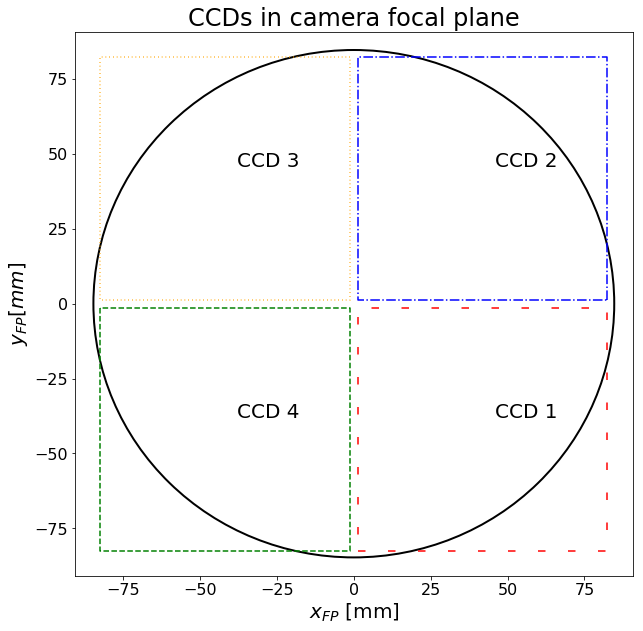

In [241]:
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111)

for ccdCode in ccdCodes:
    
    cornersX, cornersY = rf.computeCCDcornersInFocalPlane(ccdCode, pixelSize)
    
    ax.text(np.mean(cornersX) + offset, np.mean(cornersY) + offset, "CCD " + ccdCode, fontsize = 20)
    
    cornersX = np.append(cornersX, cornersX[0])
    cornersY = np.append(cornersY, cornersY[0])
    
    plt.plot(cornersX, cornersY, linestyle=linestyles[int(ccdCode) - 1], color=colors[int(ccdCode) - 1])
    
circ = plt.Circle((0, 0), radius=fovMm, color = "none", linewidth = 2)
ax.add_patch(circ)
circ.set_edgecolor("k")
circ.set_facecolor("none")

ax.set_title('CCDs in camera focal plane', fontsize = 24)
ax.set_xlabel('$x_{FP}$ [mm]', fontsize = 20)
ax.set_ylabel('$y_{FP} [mm]$', fontsize = 20)
plt.xticks(fontsize = 16)
plt.yticks(fontsize = 16)

plt.show()

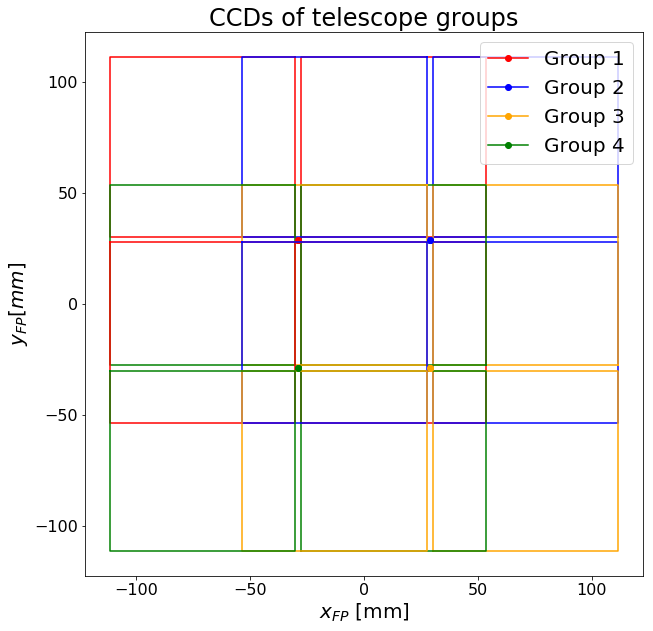

In [242]:
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111)

for ccdCode in ccdCodes:
    
    cornersX, cornersY = rf.computeCCDcornersInFocalPlane(ccdCode, pixelSize)
    cornersX = np.append(cornersX, cornersX[0])
    cornersY = np.append(cornersY, cornersY[0])
    
    for group in range(numGroups):
        
        if ccdCode == "1":
            plt.plot([xFP[group]], [yFP[group]], color=colors[group], marker="o", label = "Group " + str(group + 1))
        else:
            plt.plot([xFP[group]], [yFP[group]], color=colors[group], marker="o")
        plt.plot(cornersX + xFP[group], cornersY + yFP[group], color=colors[group])

plt.legend(prop={'size': 20})
ax.set_title('CCDs of telescope groups', fontsize = 24)
ax.set_xlabel('$x_{FP}$ [mm]', fontsize = 20)
ax.set_ylabel('$y_{FP} [mm]$', fontsize = 20)
plt.xticks(fontsize = 16)
plt.yticks(fontsize = 16)

plt.show()

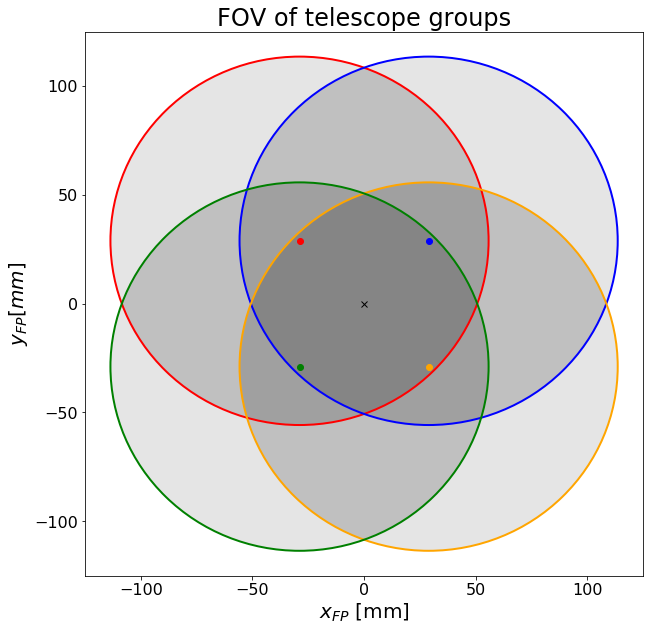

In [243]:
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111)

circles = []
for group in range(numGroups):
    circles.append(sg.Point(xFP[group], yFP[group]).buffer(fovMm))

for index in range(numCorners):
    
    one = circles[index].intersection(circles[index])
    ax.add_patch(descartes.PolygonPatch(one, fc='gray', ec='none', alpha=0.2))
    
    two = circles[index].intersection(circles[(index + 1) % numCorners])
    ax.add_patch(descartes.PolygonPatch(two, fc='gray', ec='none', alpha=0.2))
    
    three = circles[index].intersection(circles[(index + 1) % numCorners]).intersection(circles[(index + 2) % numCorners])
    ax.add_patch(descartes.PolygonPatch(three, fc='gray', ec='none', alpha=0.2))
    
four = circles[0].intersection(circles[1]).intersection(circles[2]).intersection(circles[3])
ax.add_patch(descartes.PolygonPatch(four, fc='gray', ec='none', alpha=0.2))

for group in range(numGroups):
    
    plt.plot([xFP[group]], [yFP[group]], color=colors[group], marker="o")
    
    circ = plt.Circle((xFP[group], yFP[group]), radius = fovMm, color = "none", linewidth = 2)
    ax.add_patch(circ)
    circ.set_edgecolor(colors[group])
    circ.set_facecolor("none")

plt.plot([0], [0], "kx")
    
ax.set_title('FOV of telescope groups', fontsize = 24)
ax.set_xlabel('$x_{FP}$ [mm]', fontsize = 20)
ax.set_ylabel('$y_{FP} [mm]$', fontsize = 20)
plt.xticks(fontsize = 16)
plt.yticks(fontsize = 16)

plt.show()

In [244]:
"""
ccdCode = '1'
index = 0

cornersX, cornersY = rf.computeCCDcornersInFocalPlane(ccdCode, pixelSize)
offsetX = cornersX[index] + xFP[group]
offsetY = cornersY[index] + yFP[group]

print(offsetX, offsetY)

fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111)

colors = ['b', 'r', 'g', 'k']

for ccdCode in ccdCodes:
    
    cornersX, cornersY = rf.computeCCDcornersInFocalPlane(ccdCode, pixelSize)
    cornersX = np.append(cornersX, cornersX[0])
    cornersY = np.append(cornersY, cornersY[0])
    
    cornersX -= offsetX
    cornersY -= offsetY
     
    for group in range(numGroups):
        
#         plt.plot([(xFP[group] - offsetX)], [(yFP[group] - offsetY)], color=colors[group], marker="o")
        plt.plot(cornersX + (xFP[group] - offsetX), cornersY + (yFP[group] - offsetY), color=colors[group])
        
# for group in range(numGroups):
    
#     plt.plot([(xFP[group] - offsetX)], [(yFP[group] - offsetY)], color=colors[group], marker="o")
    
#     circ = plt.Circle(((xFP[group] - offsetX), (yFP[group] - offsetY)), radius = fovMm, color = "none", linewidth = 2)
#     ax.add_patch(circ)
#     circ.set_edgecolor(colors[group])
#     circ.set_facecolor("none")

# circles = []
# for group in range(numGroups):
#     circles.append(sg.Point((xFP[group] - offsetX), (yFP[group] - offsetX).buffer(fovMm))

# for index in range(numCorners):
    
#     one = circles[index].intersection(circles[index])
#     ax.add_patch(descartes.PolygonPatch(one, fc='gray', ec='none', alpha=0.2))
    
#     two = circles[index].intersection(circles[(index + 1) % numCorners])
#     ax.add_patch(descartes.PolygonPatch(two, fc='gray', ec='none', alpha=0.2))
    
#     three = circles[index].intersection(circles[(index + 1) % numCorners]).intersection(circles[(index + 2) % numCorners])
#     ax.add_patch(descartes.PolygonPatch(three, fc='gray', ec='none', alpha=0.2))
    
# four = circles[0].intersection(circles[1]).intersection(circles[2]).intersection(circles[3])
# ax.add_patch(descartes.PolygonPatch(four, fc='gray', ec='none', alpha=0.2))

ax.set_title('Telescope pointing w.r.t. platform pointing', fontsize = 24)
ax.set_xlabel('$x_{FP}$ [mm]', fontsize = 20)
ax.set_ylabel('$y_{FP} [mm]$', fontsize = 20)
plt.xticks(fontsize = 16)
plt.yticks(fontsize = 16)

plt.show()
"""

'\nccdCode = \'1\'\nindex = 0\n\ncornersX, cornersY = rf.computeCCDcornersInFocalPlane(ccdCode, pixelSize)\noffsetX = cornersX[index] + xFP[group]\noffsetY = cornersY[index] + yFP[group]\n\nprint(offsetX, offsetY)\n\nfig = plt.figure(figsize=(10, 10))\nax = fig.add_subplot(111)\n\ncolors = [\'b\', \'r\', \'g\', \'k\']\n\nfor ccdCode in ccdCodes:\n    \n    cornersX, cornersY = rf.computeCCDcornersInFocalPlane(ccdCode, pixelSize)\n    cornersX = np.append(cornersX, cornersX[0])\n    cornersY = np.append(cornersY, cornersY[0])\n    \n    cornersX -= offsetX\n    cornersY -= offsetY\n     \n    for group in range(numGroups):\n        \n#         plt.plot([(xFP[group] - offsetX)], [(yFP[group] - offsetY)], color=colors[group], marker="o")\n        plt.plot(cornersX + (xFP[group] - offsetX), cornersY + (yFP[group] - offsetY), color=colors[group])\n        \n# for group in range(numGroups):\n    \n#     plt.plot([(xFP[group] - offsetX)], [(yFP[group] - offsetY)], color=colors[group], marker=

# CCDs

## Group 1 / CCD 1 - Group 2 / CCD 4 - Group 3 / CCD 3 - Group 4 / CCD 2

## Group 1 / CCD2 - Group 2 / CCD 1 - Group 3 / CCD 4 - Group 4 / CCD 3

## Group 1 / CCD 3 - Group 2 / CCD 2 - Group 3 / CCD 1 - Group 4 / CCD 4

## Group 1 / CCD 4 - Group 2 / CCD 3 - Group 3 / CCD 2 - Group 4 / CCD 1

## Group 1 

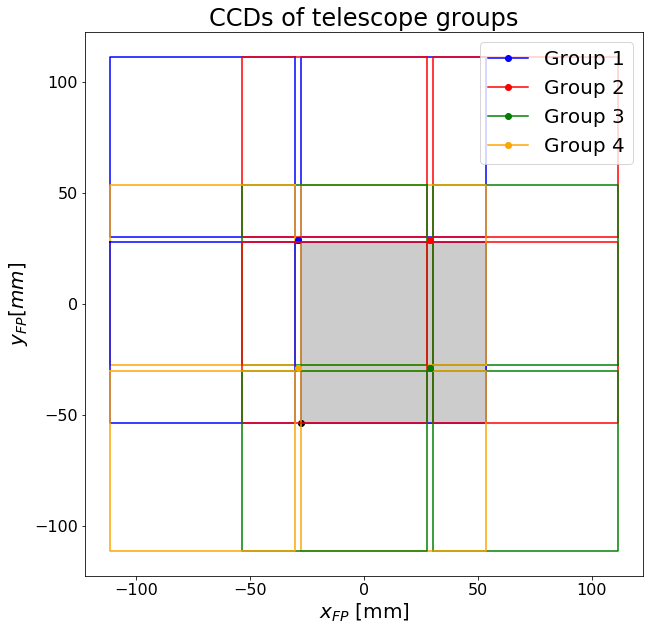

In [189]:
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111)

for ccdCode in ccdCodes:
    
    cornersX, cornersY = rf.computeCCDcornersInFocalPlane(ccdCode, pixelSize)
    cornersX = np.append(cornersX, cornersX[0])
    cornersY = np.append(cornersY, cornersY[0])
    
    for group in range(numGroups):
        
        if ccdCode == "1":
            plt.plot([xFP[group]], [yFP[group]], color=colors[group], marker="o", label = "Group " + str(group + 1))
        else:
            plt.plot([xFP[group]], [yFP[group]], color=colors[group], marker="o")
        plt.plot(cornersX + xFP[group], cornersY + yFP[group], color=colors[group])
        
        if group == 0 and ccdCode == "1":
            plt.plot([cornersX[0] + xFP[group]], [cornersY[0] + yFP[group]], "ko")
            
            dim = 4510 * pixelSize / 1000.
            rect = plt.Rectangle((cornersX[0] + xFP[group], cornersY[0] + yFP[group]), dim, dim, alpha = 0.4)
            ax.add_patch(rect)
            rect.set_edgecolor(colors[group])
            rect.set_facecolor("gray")
    
plt.legend(prop={'size': 20})
ax.set_title('CCDs of telescope groups', fontsize = 24)
ax.set_xlabel('$x_{FP}$ [mm]', fontsize = 20)
ax.set_ylabel('$y_{FP} [mm]$', fontsize = 20)
plt.xticks(fontsize = 16)
plt.yticks(fontsize = 16)

plt.show()

### CCD 1

In [132]:
refCcdCode = '1'
index = 0

cornersX, cornersY = rf.computeCCDcornersInFocalPlane(refCcdCode, pixelSize)
offsetX = cornersX[index] + xFP[group]
offsetY = cornersY[index] + yFP[group]

In [133]:
xMm = np.copy(xFP)
yMm = np.copy(yFP)

for group in range(numGroups):
    
    xMm[group] = mm2pixels(xMm[group])     # [mm] -> [pixels]
    yMm[group] = mm2pixels(yMm[group])     # [mm] -> [pixels]

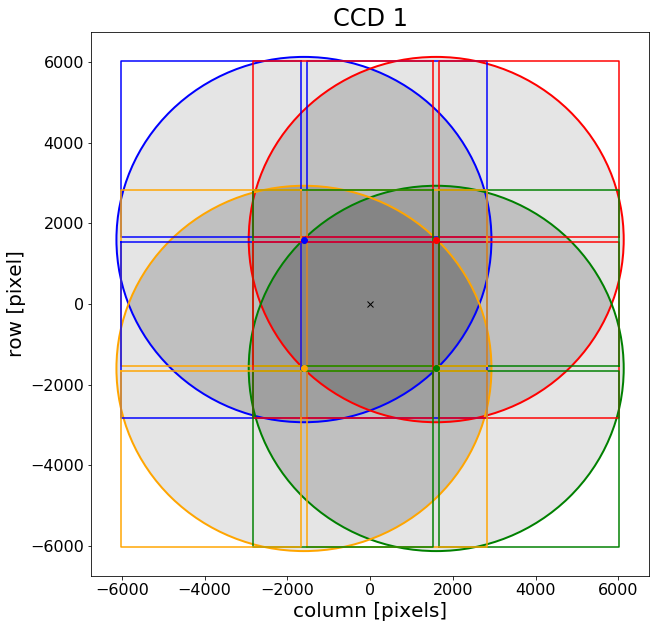

In [194]:
index = 0

cornersX, cornersY = rf.computeCCDcornersInFocalPlane(refCcdCode, pixelSize)
offsetX = mm2pixels(cornersX[index]) + xMm[group]
offsetY = mm2pixels(cornersY[index]) + yMm[group]

offsetX = 0
offsetY = 0

fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111)

circles = []
for group in range(numGroups):
    circles.append(sg.Point(xMm[group] - offsetX, yMm[group] - offsetY).buffer(fovPixels))

for index in range(numCorners):
    
    one = circles[index].intersection(circles[index])
    ax.add_patch(descartes.PolygonPatch(one, fc='gray', ec='none', alpha=0.2))
    
    two = circles[index].intersection(circles[(index + 1) % numCorners])
    ax.add_patch(descartes.PolygonPatch(two, fc='gray', ec='none', alpha=0.2))
    
    three = circles[index].intersection(circles[(index + 1) % numCorners]).intersection(circles[(index + 2) % numCorners])
    ax.add_patch(descartes.PolygonPatch(three, fc='gray', ec='none', alpha=0.2))
    
four = circles[0].intersection(circles[1]).intersection(circles[2]).intersection(circles[3])
ax.add_patch(descartes.PolygonPatch(four, fc='gray', ec='none', alpha=0.2))

for ccdCode in ccdCodes:
    
    cornersX, cornersY = rf.computeCCDcornersInFocalPlane(ccdCode, pixelSize)
    
    for corner in range(numCorners):
        cornersX[corner] = mm2pixels(cornersX[corner])
        cornersY[corner] = mm2pixels(cornersY[corner])
    
    cornersX = np.append(cornersX, cornersX[0])     # [mm]
    cornersY = np.append(cornersY, cornersY[0])     # [mm]

    
    for group in range(numGroups):
        
        arrayX = cornersX + xMm[group] - offsetX
        arrayY = cornersY + yMm[group] - offsetY
        
        for index in range(5):
            arrayX[index] = (arrayX[index])
            arrayY[index] = (arrayY[index])
        
        plt.plot(arrayX, arrayY, color=colors[group], alpha = 1)
        
for group in range(numGroups):
    
    plt.plot([(xMm[group] - offsetX)], [(yMm[group] - offsetY)], color=colors[group], marker="o")
    
    circ = plt.Circle(((xMm[group] - offsetX), (yMm[group] - offsetY)), radius = fovPixels, color = "none", linewidth = 2, alpha=1)
    ax.add_patch(circ)
    circ.set_edgecolor(colors[group])
    circ.set_facecolor("none")

plt.plot([0], [0], "kx")

ax.set_title('CCD 1', fontsize = 24)
ax.set_xlabel('column [pixels]', fontsize = 20)
ax.set_ylabel('row [pixel]', fontsize = 20)
plt.xticks(fontsize = 16)
plt.yticks(fontsize = 16)

plt.show()

## CCD 2

In [195]:
refCcdCode = '2'
index = 0

cornersX, cornersY = rf.computeCCDcornersInFocalPlane(refCcdCode, pixelSize)
offsetX = cornersX[index] + xFP[group]
offsetY = cornersY[index] + yFP[group]

In [107]:
xMm = np.copy(xFP)
yMm = np.copy(yFP)

for group in range(numGroups):
    
    xMm[group] = mm2pixels(xMm[group])     # [mm] -> [pixels]
    yMm[group] = mm2pixels(yMm[group])     # [mm] -> [pixels]

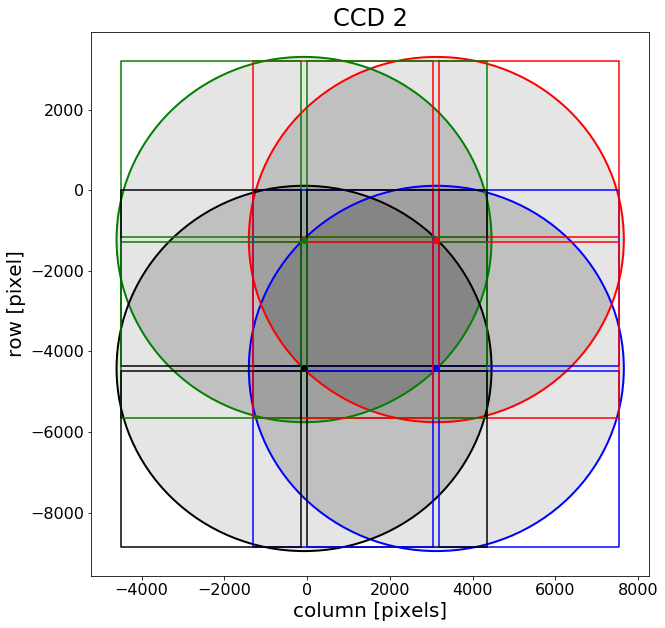

In [108]:
index = 0

cornersX, cornersY = rf.computeCCDcornersInFocalPlane(refCcdCode, pixelSize)
offsetX = mm2pixels(cornersX[index]) + xMm[group]
offsetY = mm2pixels(cornersY[index]) + yMm[group]

fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111)

colors = ['b', 'r', 'g', 'k']

circles = []
for group in range(numGroups):
    circles.append(sg.Point(yMm[group] - offsetY, xMm[group] - offsetX).buffer(fovPixels))

for index in range(numCorners):
    
    one = circles[index].intersection(circles[index])
    ax.add_patch(descartes.PolygonPatch(one, fc='gray', ec='none', alpha=0.2))
    
    two = circles[index].intersection(circles[(index + 1) % numCorners])
    ax.add_patch(descartes.PolygonPatch(two, fc='gray', ec='none', alpha=0.2))
    
    three = circles[index].intersection(circles[(index + 1) % numCorners]).intersection(circles[(index + 2) % numCorners])
    ax.add_patch(descartes.PolygonPatch(three, fc='gray', ec='none', alpha=0.2))
    
four = circles[0].intersection(circles[1]).intersection(circles[2]).intersection(circles[3])
ax.add_patch(descartes.PolygonPatch(four, fc='gray', ec='none', alpha=0.2))

for ccdCode in ccdCodes:
    
    cornersX, cornersY = rf.computeCCDcornersInFocalPlane(ccdCode, pixelSize)
    
    for corner in range(numCorners):
        cornersX[corner] = mm2pixels(cornersX[corner])
        cornersY[corner] = mm2pixels(cornersY[corner])
    
    cornersX = np.append(cornersX, cornersX[0])     # [mm]
    cornersY = np.append(cornersY, cornersY[0])     # [mm]

    
    for group in range(numGroups):
        
        arrayX = cornersX + xMm[group] - offsetX
        arrayY = cornersY + yMm[group] - offsetY
        
        for index in range(5):
            arrayX[index] = (arrayX[index])
            arrayY[index] = (arrayY[index])
        
        plt.plot(arrayY, arrayX, color=colors[group])
        
for group in range(numGroups):
    
    plt.plot([(yMm[group] - offsetY)], [(xMm[group] - offsetX)], color=colors[group], marker="o")
    
    circ = plt.Circle(((yMm[group] - offsetY), (xMm[group] - offsetX)), radius = fovPixels, color = "none", linewidth = 2)
    ax.add_patch(circ)
    circ.set_edgecolor(colors[group])
    circ.set_facecolor("none")

ax.set_title('CCD 2', fontsize = 24)
ax.set_xlabel('column [pixels]', fontsize = 20)
ax.set_ylabel('row [pixel]', fontsize = 20)
plt.xticks(fontsize = 16)
plt.yticks(fontsize = 16)

plt.show()

## CCD 3

In [109]:
refCcdCode = '3'
index = 0

cornersX, cornersY = rf.computeCCDcornersInFocalPlane(refCcdCode, pixelSize)
offsetX = cornersX[index] + xFP[group]
offsetY = cornersY[index] + yFP[group]

In [110]:
xMm = np.copy(xFP)
yMm = np.copy(yFP)

for group in range(numGroups):
    
    xMm[group] = mm2pixels(xMm[group])     # [mm] -> [pixels]
    yMm[group] = mm2pixels(yMm[group])     # [mm] -> [pixels]

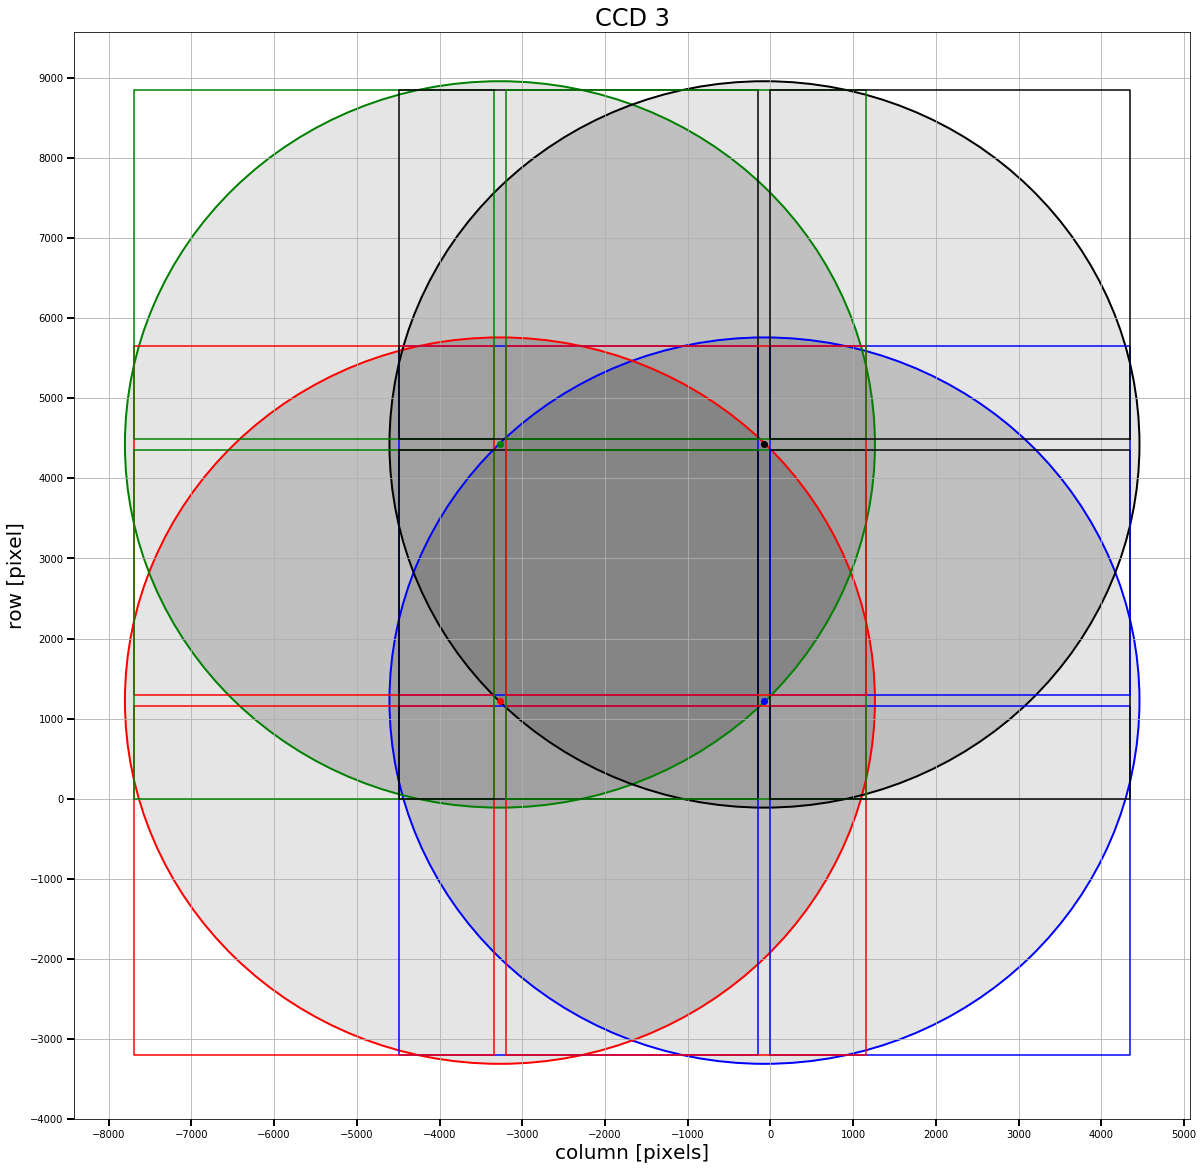

In [111]:
index = 0

cornersX, cornersY = rf.computeCCDcornersInFocalPlane(refCcdCode, pixelSize)
offsetX = mm2pixels(cornersX[index]) + xMm[group]
offsetY = mm2pixels(cornersY[index]) + yMm[group]

fig = plt.figure(figsize=(20, 20))
ax = fig.add_subplot(111)

colors = ['b', 'r', 'g', 'k']

circles = []
for group in range(numGroups):
    circles.append(sg.Point(-xMm[group] + offsetX, -yMm[group] + offsetY).buffer(fovPixels))

for index in range(numCorners):
    
    one = circles[index].intersection(circles[index])
    ax.add_patch(descartes.PolygonPatch(one, fc='gray', ec='none', alpha=0.2))
    
    two = circles[index].intersection(circles[(index + 1) % numCorners])
    ax.add_patch(descartes.PolygonPatch(two, fc='gray', ec='none', alpha=0.2))
    
    three = circles[index].intersection(circles[(index + 1) % numCorners]).intersection(circles[(index + 2) % numCorners])
    ax.add_patch(descartes.PolygonPatch(three, fc='gray', ec='none', alpha=0.2))
    
four = circles[0].intersection(circles[1]).intersection(circles[2]).intersection(circles[3])
ax.add_patch(descartes.PolygonPatch(four, fc='gray', ec='none', alpha=0.2))

for ccdCode in ccdCodes:
    
    cornersX, cornersY = rf.computeCCDcornersInFocalPlane(ccdCode, pixelSize)
    
    for corner in range(numCorners):
        cornersX[corner] = mm2pixels(cornersX[corner])
        cornersY[corner] = mm2pixels(cornersY[corner])
    
    cornersX = np.append(cornersX, cornersX[0])     # [mm]
    cornersY = np.append(cornersY, cornersY[0])     # [mm]

    
    for group in range(numGroups):
        
        arrayX = cornersX + xMm[group] - offsetX
        arrayY = cornersY + yMm[group] - offsetY
        
        for index in range(5):
            arrayX[index] = (arrayX[index])
            arrayY[index] = (arrayY[index])
        
        plt.plot(-arrayX, -arrayY, color=colors[group])
        
for group in range(numGroups):
    
    plt.plot([(-xMm[group] + offsetX)], [(-yMm[group] + offsetY)], color=colors[group], marker="o")
    
    circ = plt.Circle(((-xMm[group] + offsetX), (-yMm[group] + offsetY)), radius = fovPixels, color = "none", linewidth = 2)
    ax.add_patch(circ)
    circ.set_edgecolor(colors[group])
    circ.set_facecolor("none")

ax.set_title('CCD 3', fontsize = 24)
ax.set_xlabel('column [pixels]', fontsize = 20)
ax.set_ylabel('row [pixel]', fontsize = 20)
# plt.xticks(fontsize = 16)
# plt.yticks(fontsize = 16)

from matplotlib.ticker import (MultipleLocator, FormatStrFormatter,
                               AutoMinorLocator)
# ax.xaxis.set_minor_locator(AutoMinorLocator())

ax.tick_params(which='both', width=2)
ax.tick_params(which='major', length=7)
ax.tick_params(which='minor', length=4, color='r')
ax.grid(True)
ax.set_xticks([-8000, -7000, -6000, -5000, -4000, -3000, -2000, -1000, 0, 1000, 2000, 3000, 4000, 5000])
ax.set_yticks([-4000, -3000, -2000, -1000, 0, 1000, 2000, 3000, 4000, 5000, 6000, 7000, 8000, 9000])

plt.show()

## CCD 4

In [112]:
refCcdCode = '4'
index = 0

cornersX, cornersY = rf.computeCCDcornersInFocalPlane(refCcdCode, pixelSize)
offsetX = cornersX[index] + xFP[group]
offsetY = cornersY[index] + yFP[group]

In [113]:
xMm = np.copy(xFP)
yMm = np.copy(yFP)

for group in range(numGroups):
    
    xMm[group] = mm2pixels(xMm[group])     # [mm] -> [pixels]
    yMm[group] = mm2pixels(yMm[group])     # [mm] -> [pixels]

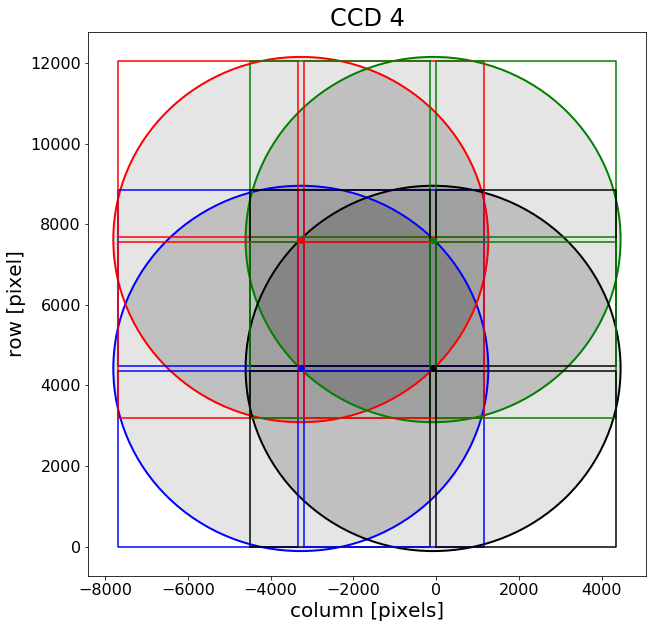

In [114]:
index = 0

cornersX, cornersY = rf.computeCCDcornersInFocalPlane(refCcdCode, pixelSize)
offsetX = mm2pixels(cornersX[index]) + xMm[group]
offsetY = mm2pixels(cornersY[index]) + yMm[group]

fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111)

colors = ['b', 'r', 'g', 'k']

circles = []
for group in range(numGroups):
    circles.append(sg.Point(-yMm[group] + offsetY, xMm[group] - offsetX).buffer(fovPixels))

for index in range(numCorners):
    
    one = circles[index].intersection(circles[index])
    ax.add_patch(descartes.PolygonPatch(one, fc='gray', ec='none', alpha=0.2))
    
    two = circles[index].intersection(circles[(index + 1) % numCorners])
    ax.add_patch(descartes.PolygonPatch(two, fc='gray', ec='none', alpha=0.2))
    
    three = circles[index].intersection(circles[(index + 1) % numCorners]).intersection(circles[(index + 2) % numCorners])
    ax.add_patch(descartes.PolygonPatch(three, fc='gray', ec='none', alpha=0.2))
    
four = circles[0].intersection(circles[1]).intersection(circles[2]).intersection(circles[3])
ax.add_patch(descartes.PolygonPatch(four, fc='gray', ec='none', alpha=0.2))

for ccdCode in ccdCodes:
    
    cornersX, cornersY = rf.computeCCDcornersInFocalPlane(ccdCode, pixelSize)
    
    for corner in range(numCorners):
        cornersX[corner] = mm2pixels(cornersX[corner])
        cornersY[corner] = mm2pixels(cornersY[corner])
    
    cornersX = np.append(cornersX, cornersX[0])     # [mm]
    cornersY = np.append(cornersY, cornersY[0])     # [mm]

    
    for group in range(numGroups):
        
        arrayX = cornersX + xMm[group] - offsetX
        arrayY = cornersY + yMm[group] - offsetY
        
        for index in range(5):
            arrayX[index] = (arrayX[index])
            arrayY[index] = (arrayY[index])
        
        plt.plot(-arrayY, arrayX, color=colors[group])
        
for group in range(numGroups):
    
    plt.plot([(-yMm[group] + offsetY)], [(xMm[group] - offsetX)], color=colors[group], marker="o")
    
    circ = plt.Circle(((-yMm[group] + offsetY), (xMm[group] - offsetX)), radius = fovPixels, color = "none", linewidth = 2)
    ax.add_patch(circ)
    circ.set_edgecolor(colors[group])
    circ.set_facecolor("none")

ax.set_title('CCD 4', fontsize = 24)
ax.set_xlabel('column [pixels]', fontsize = 20)
ax.set_ylabel('row [pixel]', fontsize = 20)
plt.xticks(fontsize = 16)
plt.yticks(fontsize = 16)

plt.show()